In [1]:
# Cell 1 — Load isochrones + SDSS field CSVs (target + controls), and build "error-bar overlap" candidates

import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

# -----------------------------
# CONFIG
# -----------------------------
ISO_DIR = "isochrones"             # folder used by your dartmouth loader
FIELDS_DIR = "sdss_data/fields"
PATTERN = os.path.join(FIELDS_DIR, "sdss_*.csv")   # includes sdss_target.csv too

# Sgr reference distance (for shifting isochrones to apparent mags)
d_pc = 33_400.0
DM_SGR = 5.0 * np.log10(d_pc / 10.0)

# quality cuts (keep light; you can tighten later)
ERR_MAX = 0.15
G0_MAX  = 23.5
R0_MAX  = 23.5

# overlap tolerance (to avoid being hypersensitive to tiny numerical gaps)
# Think of this as "additional model/isochrone thickness" in magnitudes
ISO_PAD = 0.02

# -----------------------------
# 1) Load Dartmouth isochrones
# -----------------------------
from isochrones.dartmouth_iso import load_isochrones
isos = load_isochrones(ISO_DIR)

iso5  = isos["5gyr"]
iso13 = isos["13gyr"]

def iso_to_apparent_arrays(iso, DM):
    """Return arrays for an isochrone shifted to apparent mags at DM."""
    df_iso = iso.df
    g_app = (df_iso["sdss_g"].to_numpy()) + DM
    r_app = (df_iso["sdss_r"].to_numpy()) + DM
    c_app = g_app - r_app
    return c_app, g_app

c5_iso,  g5_iso  = iso_to_apparent_arrays(iso5,  DM_SGR)
c13_iso, g13_iso = iso_to_apparent_arrays(iso13, DM_SGR)

# -----------------------------
# 2) Load SDSS field CSVs and compute dereddened mags + errors
# -----------------------------
def load_sdss_field(path):
    df = pd.read_csv(path, comment="#")

    # dereddened mags/colors
    df["g0"]  = df["psfMag_g"] - df["extinction_g"]
    df["r0"]  = df["psfMag_r"] - df["extinction_r"]
    df["g_r"] = df["g0"] - df["r0"]

    # photometric errors (assume columns exist)
    df["sig_g"]  = df["psfMagErr_g"]
    df["sig_r"]  = df["psfMagErr_r"]
    df["sig_gr"] = np.sqrt(df["sig_g"]**2 + df["sig_r"]**2)

    # light quality mask
    m = (
        (df["sig_g"] < ERR_MAX) &
        (df["sig_r"] < ERR_MAX) &
        (df["g0"] < G0_MAX) &
        (df["r0"] < R0_MAX)
    )
    return df[m].copy()

paths = sorted([p for p in glob.glob(PATTERN) if "FAILED_" not in os.path.basename(p)])
if not paths:
    raise FileNotFoundError(f"No files matched {PATTERN}")

fields = []
for p in paths:
    fid = os.path.basename(p).replace("sdss_", "").replace(".csv", "")
    fields.append((fid, load_sdss_field(p)))

field_map = {fid: df for fid, df in fields}
print(f"Loaded {len(fields)} fields. Target present? {'target' in field_map}")

# -----------------------------
# 3) Candidate definition: error bars overlap isochrone (rectangle overlap)
# -----------------------------
def candidates_by_errorbar_overlap(df, c_iso, g_iso, iso_pad=0.0):
    """
    A star is a candidate if there exists at least one isochrone point (c_i, g_i)
    that lies within the star's (color,mag) error rectangle:
        |c_i - c_star| <= sig_color + iso_pad
        |g_i - g_star| <= sig_g + iso_pad

    Returns boolean mask of length len(df).
    """
    c_star = df["g_r"].to_numpy()
    g_star = df["g0"].to_numpy()
    sc     = df["sig_gr"].to_numpy()
    sg     = df["sig_g"].to_numpy()

    cand = np.zeros(len(df), dtype=bool)

    # Vectorized per-star scan (fast enough for a few thousand stars x a few thousand iso points)
    # We do a two-stage gate: first mag window, then color window.
    for j in range(len(df)):
        m_mag = np.abs(g_iso - g_star[j]) <= (sg[j] + iso_pad)
        if not np.any(m_mag):
            continue
        # only check colors for mag-compatible iso points
        if np.any(np.abs(c_iso[m_mag] - c_star[j]) <= (sc[j] + iso_pad)):
            cand[j] = True
    return cand

# compute candidate masks for target + all controls, for both isochrones
for fid, df in fields:
    df["cand_5_overlap"]  = candidates_by_errorbar_overlap(df, c5_iso,  g5_iso,  iso_pad=ISO_PAD)
    df["cand_13_overlap"] = candidates_by_errorbar_overlap(df, c13_iso, g13_iso, iso_pad=ISO_PAD)
    df["cand_either_overlap"] = df["cand_5_overlap"] | df["cand_13_overlap"]

print("Example (target):",
      field_map["target"]["cand_either_overlap"].sum(),
      "candidates out of",
      len(field_map["target"]))

Loaded 14 fields. Target present? True
Example (target): 880 candidates out of 3206


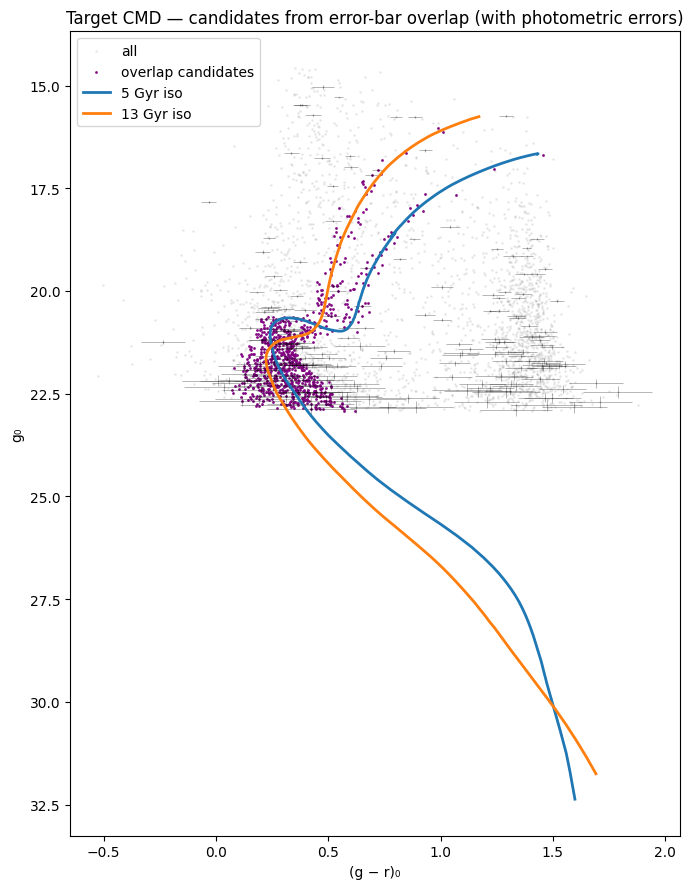

Target candidates: 880 out of 3206


In [2]:
# Cell 2 — Plot target CMD with overlap-selected candidates + error bars

df_t = field_map["target"]

plt.figure(figsize=(7,9))

# -----------------------------
# 1) All stars (background)
# -----------------------------
plt.scatter(df_t["g_r"], df_t["g0"], s=1, alpha=0.12, color="gray", label="all")

# -----------------------------
# 2) Candidates
# -----------------------------
cand_mask = df_t["cand_either_overlap"]

plt.scatter(df_t.loc[cand_mask, "g_r"],
            df_t.loc[cand_mask, "g0"],
            s=1, alpha=0.9, color="purple", 
            label="overlap candidates")

# -----------------------------
# 3) Plot error bars (subset only to avoid clutter)
# -----------------------------
N_ERR = 200   # increase/decrease as desired
sample_idx = np.random.choice(df_t.index, size=min(N_ERR, len(df_t)), replace=False)
df_err = df_t.loc[sample_idx]

plt.errorbar(
    df_err["g_r"],
    df_err["g0"],
    xerr=df_err["sig_gr"],   # color uncertainty (quadrature sum)
    yerr=df_err["sig_g"],    # magnitude uncertainty
    fmt="none",
    ecolor="black",
    elinewidth=0.5,
    alpha=0.4,
    capsize=0
)

# -----------------------------
# 4) Isochrones
# -----------------------------
plt.plot(c5_iso,  g5_iso,  lw=2, label="5 Gyr iso")
plt.plot(c13_iso, g13_iso, lw=2, label="13 Gyr iso")

# -----------------------------
# Formatting
# -----------------------------
plt.gca().invert_yaxis()
plt.xlabel("(g − r)₀")
plt.ylabel("g₀")
plt.title("Target CMD — candidates from error-bar overlap (with photometric errors)")
plt.legend()
plt.tight_layout()
plt.show()

print("Target candidates:",
      df_t["cand_either_overlap"].sum(),
      "out of", len(df_t))

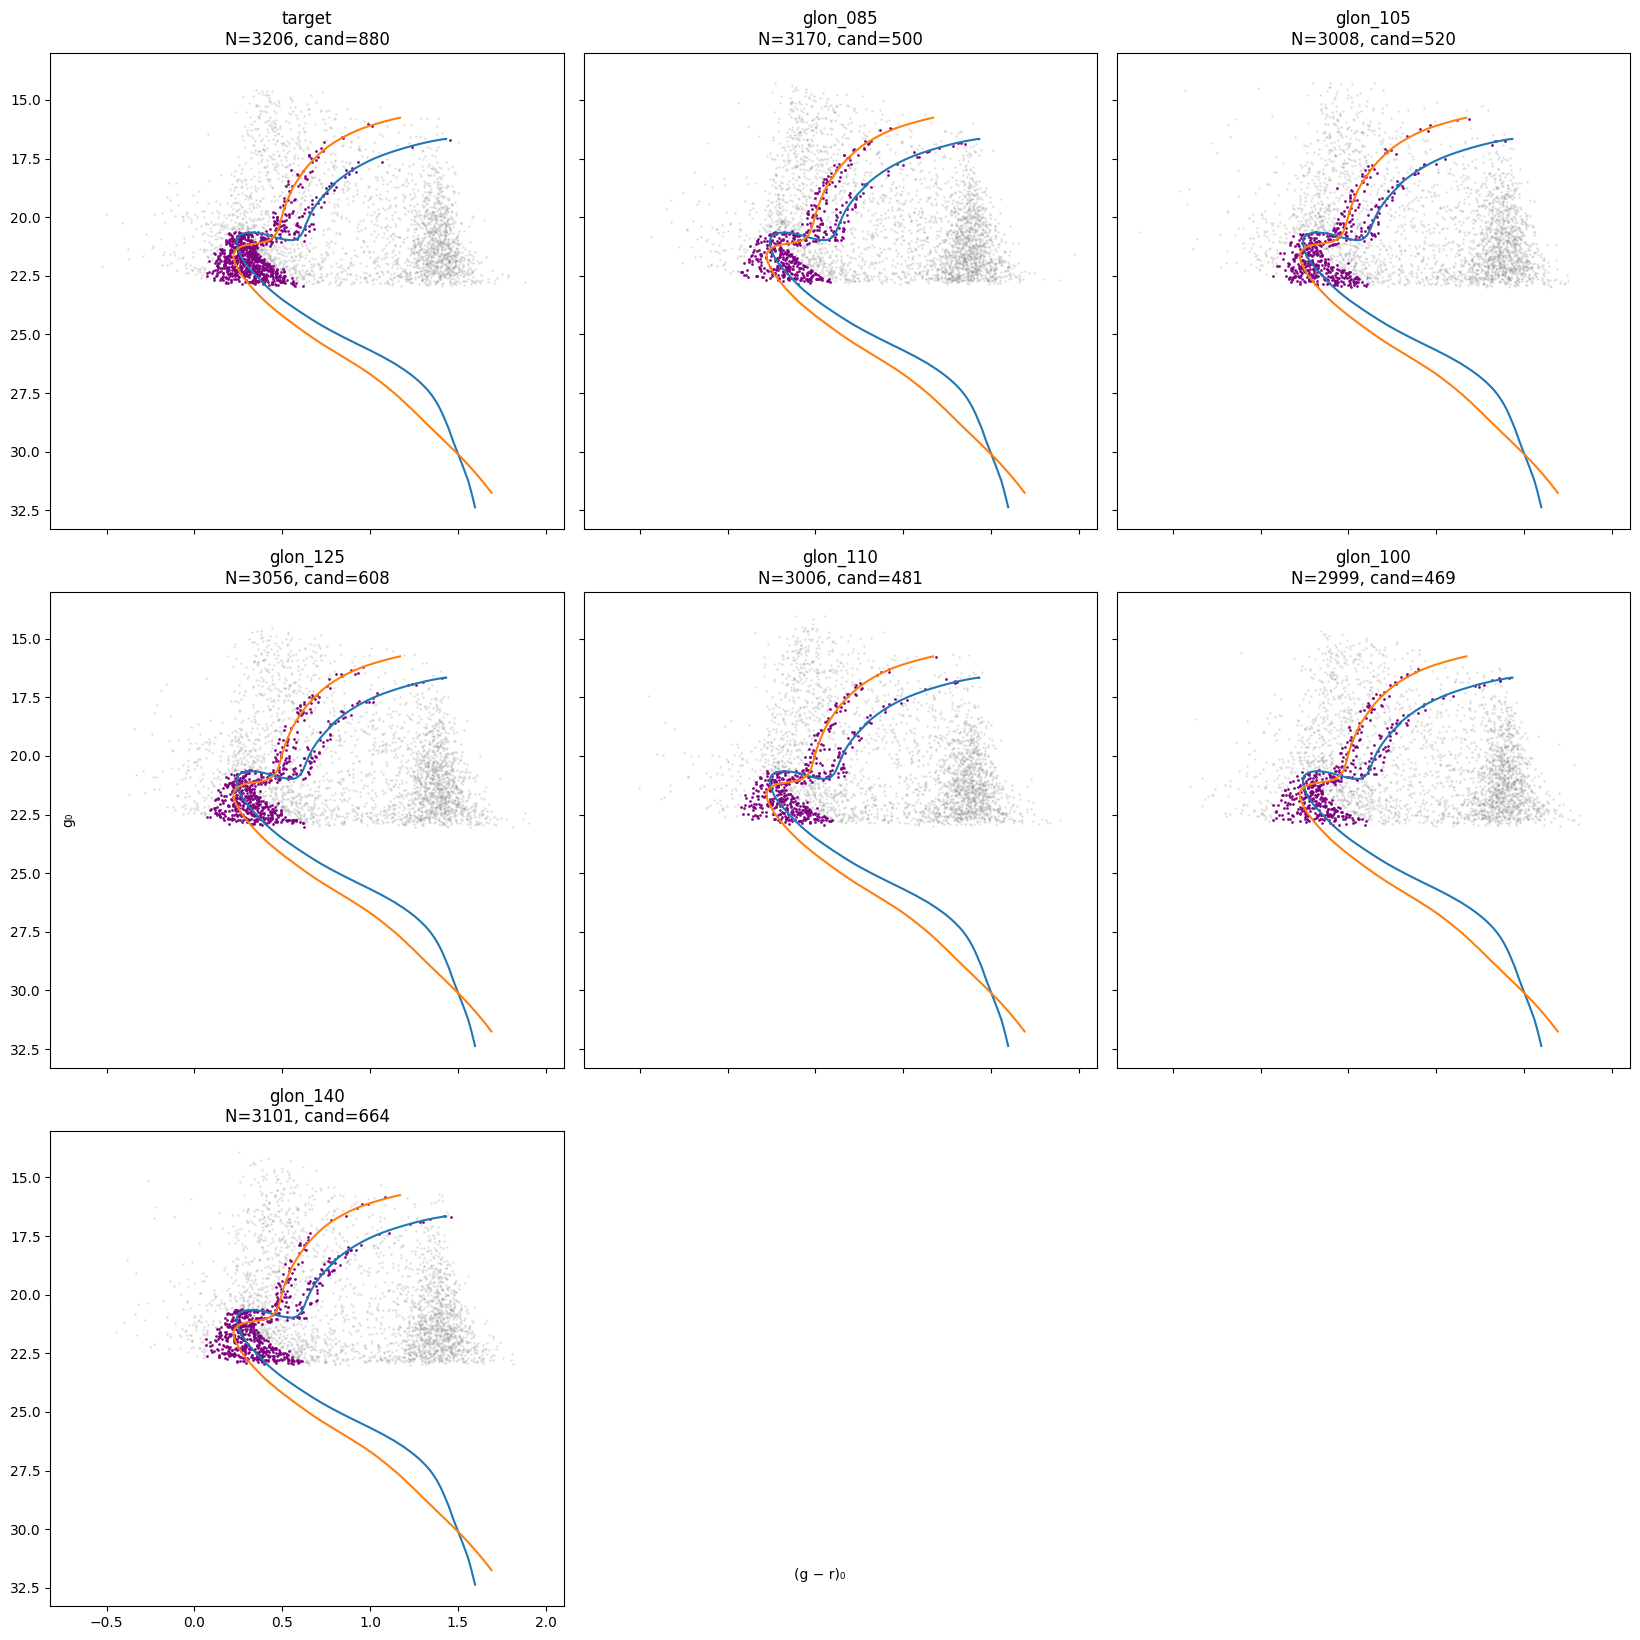

In [3]:
# Cell 3 — CMDs for target + a handful of controls

import random

control_ids = [fid for fid in field_map.keys() if fid != "target"]
plot_ids = ["target"] + random.sample(control_ids, k=min(6, len(control_ids)))

n = len(plot_ids)
ncols = 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5.5*ncols, 5.5*nrows),
                         sharex=True, sharey=True)
axes = np.array(axes).reshape(-1)

for ax, fid in zip(axes, plot_ids):
    dfp = field_map[fid]

    ax.scatter(dfp["g_r"], dfp["g0"], s=1, alpha=0.15, color="gray")
    ax.scatter(dfp.loc[dfp["cand_either_overlap"], "g_r"],
               dfp.loc[dfp["cand_either_overlap"], "g0"],
               s=1, alpha=0.9, color="purple")

    ax.plot(c5_iso,  g5_iso,  lw=1.5)
    ax.plot(c13_iso, g13_iso, lw=1.5)

    N  = len(dfp)
    Nc = int(dfp["cand_either_overlap"].sum())

    ax.set_title(f"{fid}\nN={N}, cand={Nc}")
    ax.invert_yaxis()

for k in range(len(plot_ids), len(axes)):
    axes[k].axis("off")

fig.text(0.5, 0.04, "(g − r)₀", ha="center")
fig.text(0.04, 0.5, "g₀", va="center", rotation="vertical")
plt.tight_layout()
plt.show()

,field,N,N_cand,f_cand
0,glon_080,3117,501,0.160731
1,glon_085,3170,500,0.157729
2,glon_090,3069,503,0.163897
3,glon_095,3061,513,0.167592
4,glon_100,2999,469,0.156385
5,glon_105,3008,520,0.172872
6,glon_110,3006,481,0.160013
7,glon_115,3037,498,0.163978
8,glon_120,2958,474,0.160243
9,glon_125,3056,608,0.198953


=== Overdensity (error-bar overlap candidates) ===
Target:    N=3206, N_cand=880, f=0.27449
Controls:  mean f=0.17387, std f=0.02040  (n=13)
Excess:    Δf=0.10062
Significance: S = 4.93 σ
Empirical one-sided p-value: p = 0.071


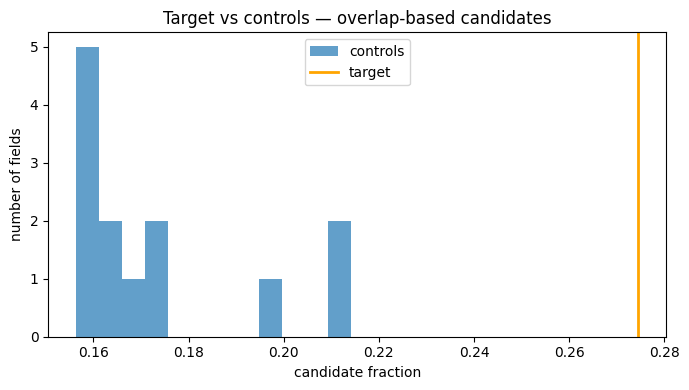

In [4]:
# Cell 4 — Overdensity statistic using overlap candidates

rows = []
for fid, dfp in fields:
    N  = len(dfp)
    Nc = int(dfp["cand_either_overlap"].sum())
    f  = Nc / N if N > 0 else np.nan
    rows.append({"field": fid, "N": N, "N_cand": Nc, "f_cand": f})

summary = pd.DataFrame(rows).sort_values("field")
display(summary)

target_row = summary[summary["field"] == "target"].iloc[0]
controls   = summary[(summary["field"] != "target") & np.isfinite(summary["f_cand"])]

mu = controls["f_cand"].mean()
sigma = controls["f_cand"].std(ddof=1)
S = (target_row["f_cand"] - mu) / sigma if sigma > 0 else np.nan

print("=== Overdensity (error-bar overlap candidates) ===")
print(f"Target:    N={int(target_row['N'])}, N_cand={int(target_row['N_cand'])}, f={target_row['f_cand']:.5f}")
print(f"Controls:  mean f={mu:.5f}, std f={sigma:.5f}  (n={len(controls)})")
print(f"Excess:    Δf={target_row['f_cand']-mu:.5f}")
print(f"Significance: S = {S:.2f} σ")

# empirical p-value
ctrl_f = controls["f_cand"].to_numpy()
p = (np.sum(ctrl_f >= target_row["f_cand"]) + 1) / (len(ctrl_f) + 1)
print(f"Empirical one-sided p-value: p = {p:.3f}")

plt.figure(figsize=(7,4))
plt.hist(ctrl_f, bins=12, alpha=0.7, label="controls")
plt.axvline(target_row["f_cand"], linewidth=2, label="target", color="orange")
plt.xlabel("candidate fraction")
plt.ylabel("number of fields")
plt.title("Target vs controls — overlap-based candidates")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
# Cell 5 — MSTO-only overdensity (same simple overlap logic)

# conservative MSTO box — adjust if needed
msto = dict(gmin=20.0, gmax=22.5, cmin=0.15, cmax=0.65)

rows = []
for fid, dfp in fields:

    m = (
        (dfp["g0"] >= msto["gmin"]) &
        (dfp["g0"] <= msto["gmax"]) &
        (dfp["g_r"] >= msto["cmin"]) &
        (dfp["g_r"] <= msto["cmax"])
    )

    sub = dfp[m]
    N  = len(sub)
    Nc = int(sub["cand_either_overlap"].sum())
    f  = Nc / N if N > 0 else np.nan

    rows.append({"field": fid, "N_msto": N, "N_cand": Nc, "f_cand": f})

summary_msto = pd.DataFrame(rows).sort_values("field")
display(summary_msto)

target_row = summary_msto[summary_msto["field"] == "target"].iloc[0]
controls   = summary_msto[(summary_msto["field"] != "target") & np.isfinite(summary_msto["f_cand"])]

mu = controls["f_cand"].mean()
sigma = controls["f_cand"].std(ddof=1)
S = (target_row["f_cand"] - mu) / sigma if sigma > 0 else np.nan

print("=== Overdensity (MSTO only, overlap candidates) ===")
print(f"Target:    N={int(target_row['N_msto'])}, N_cand={int(target_row['N_cand'])}, f={target_row['f_cand']:.5f}")
print(f"Controls:  mean f={mu:.5f}, std f={sigma:.5f}  (n={len(controls)})")
print(f"Significance: S = {S:.2f} σ")

,field,N_msto,N_cand,f_cand
0,glon_080,584,349,0.597603
1,glon_085,570,309,0.542105
2,glon_090,599,348,0.580968
3,glon_095,555,313,0.563964
4,glon_100,545,274,0.502752
5,glon_105,569,321,0.564148
6,glon_110,539,295,0.547310
7,glon_115,548,298,0.543796
8,glon_120,519,287,0.552987
9,glon_125,614,370,0.602606


=== Overdensity (MSTO only, overlap candidates) ===
Target:    N=899, N_cand=632, f=0.70300
Controls:  mean f=0.57318, std f=0.03781  (n=13)
Significance: S = 3.43 σ
